In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import *
from keras.preprocessing.image import ImageDataGenerator
from keras.applications.vgg16 import preprocess_input
import tensorflow as tf
from tensorflow.keras.models import Model

test_path = r"D:\datasets\COVID-19\COVID-19_Radiography_Dataset"
labels = [i for i in os.listdir(test_path) if "." not in i]
CLASSES = len(labels)

model = tf.keras.models.load_model(r"e:\Project\COVID project\models\best_m_epoch_06_acc0.9481_loss0.1388_val_acc0.9467.h5")


In [4]:
# Check if a GPU is available
physical_devices = tf.config.list_physical_devices()
num_gpus = len(physical_devices)

if num_gpus >= 1:
    # Set the GPU device to use
    gpu_device = physical_devices[1].name
    print(f"Using GPU: {gpu_device}")

    # Allow TensorFlow to use the GPU for computation
    tf.config.set_visible_devices(physical_devices[1:], 'GPU')
      # Adjust this value as needed

else:
    print("Please run on a machine with a CUDA device installed")

Using GPU: /physical_device:GPU:0


In [5]:
height, width = 299, 299
img_size = (height, width)
bs = 32
seed = 123

datagen = ImageDataGenerator(
    validation_split=0.2,
)
test_generator = datagen.flow_from_directory(
    test_path,
    target_size=(height, width), 
    subset="validation",
    batch_size=bs, 
    class_mode="categorical",
    color_mode="grayscale"
)

Found 4232 images belonging to 4 classes.


## accuracy on test

Accuracy on test set: 0.9672
Total: 4232 | Correct: 4093 | Wrong: 139


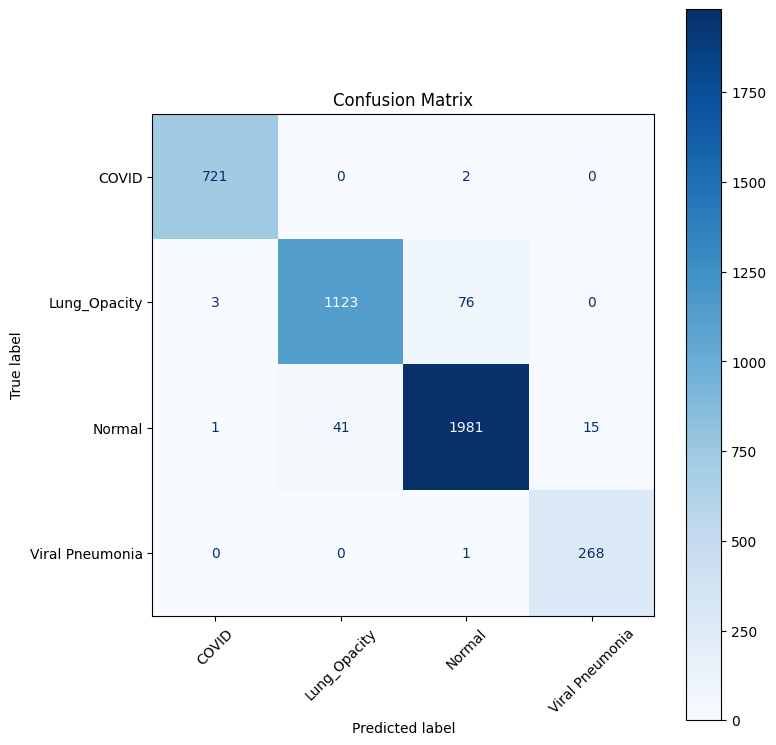


Classification Report:
                 precision    recall  f1-score   support

          COVID       0.99      1.00      1.00       723
   Lung_Opacity       0.96      0.93      0.95      1202
         Normal       0.96      0.97      0.97      2038
Viral Pneumonia       0.95      1.00      0.97       269

       accuracy                           0.97      4232
      macro avg       0.97      0.97      0.97      4232
   weighted avg       0.97      0.97      0.97      4232



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Reset the generator so predictions start from the beginning of the dataset
test_generator.reset()

y_true = []
y_pred = []

# Number of batches needed to cover the full test dataset
steps = int(np.ceil(test_generator.samples / bs))

for i in range(steps):
    img, lbl = next(test_generator)
    predictions = model.predict(img, verbose=0)

    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(np.argmax(lbl, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Overall accuracy on the test dataset
accuracy = np.mean(y_true == y_pred)
print(f"Accuracy on test set: {accuracy:.4f}")
print(f"Total: {len(y_true)} | Correct: {np.sum(y_true == y_pred)} | Wrong: {np.sum(y_true != y_pred)}")

# Build and display the confusion matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", colorbar=True)
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Full precision / recall / f1-score report for each class
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=labels))


## predict a batch with visualise photos

In [7]:
t, f = 0, 0
test_gen1 = test_generator
image_batch, label_batch = next(test_gen1)
# Make predictions for the selected image batch
predictions = model.predict(image_batch)
for i in range(bs):
    # Select a prediction from the batch
    pred = predictions[i]

    # Get the predicted label and its confidence
    predicted_label = np.argmax(pred)
    test_label = np.argmax(label_batch[i])
    if predicted_label== test_label:
        t +=1
    else: 
        f+=1
    confidence = pred[predicted_label]
print(t, f)
accuracy = t / (t+f)
loss = (1/bs) * pow(f, 2)
accuracy, loss

1/1 [==============================] - 0s 37ms/step
32 0


(1.0, 0.0)

1/1 [==============================] - 0s 24ms/step
accuracy is:  0.9375 
loss is:  0.125 . 30 true confidence in 32 data


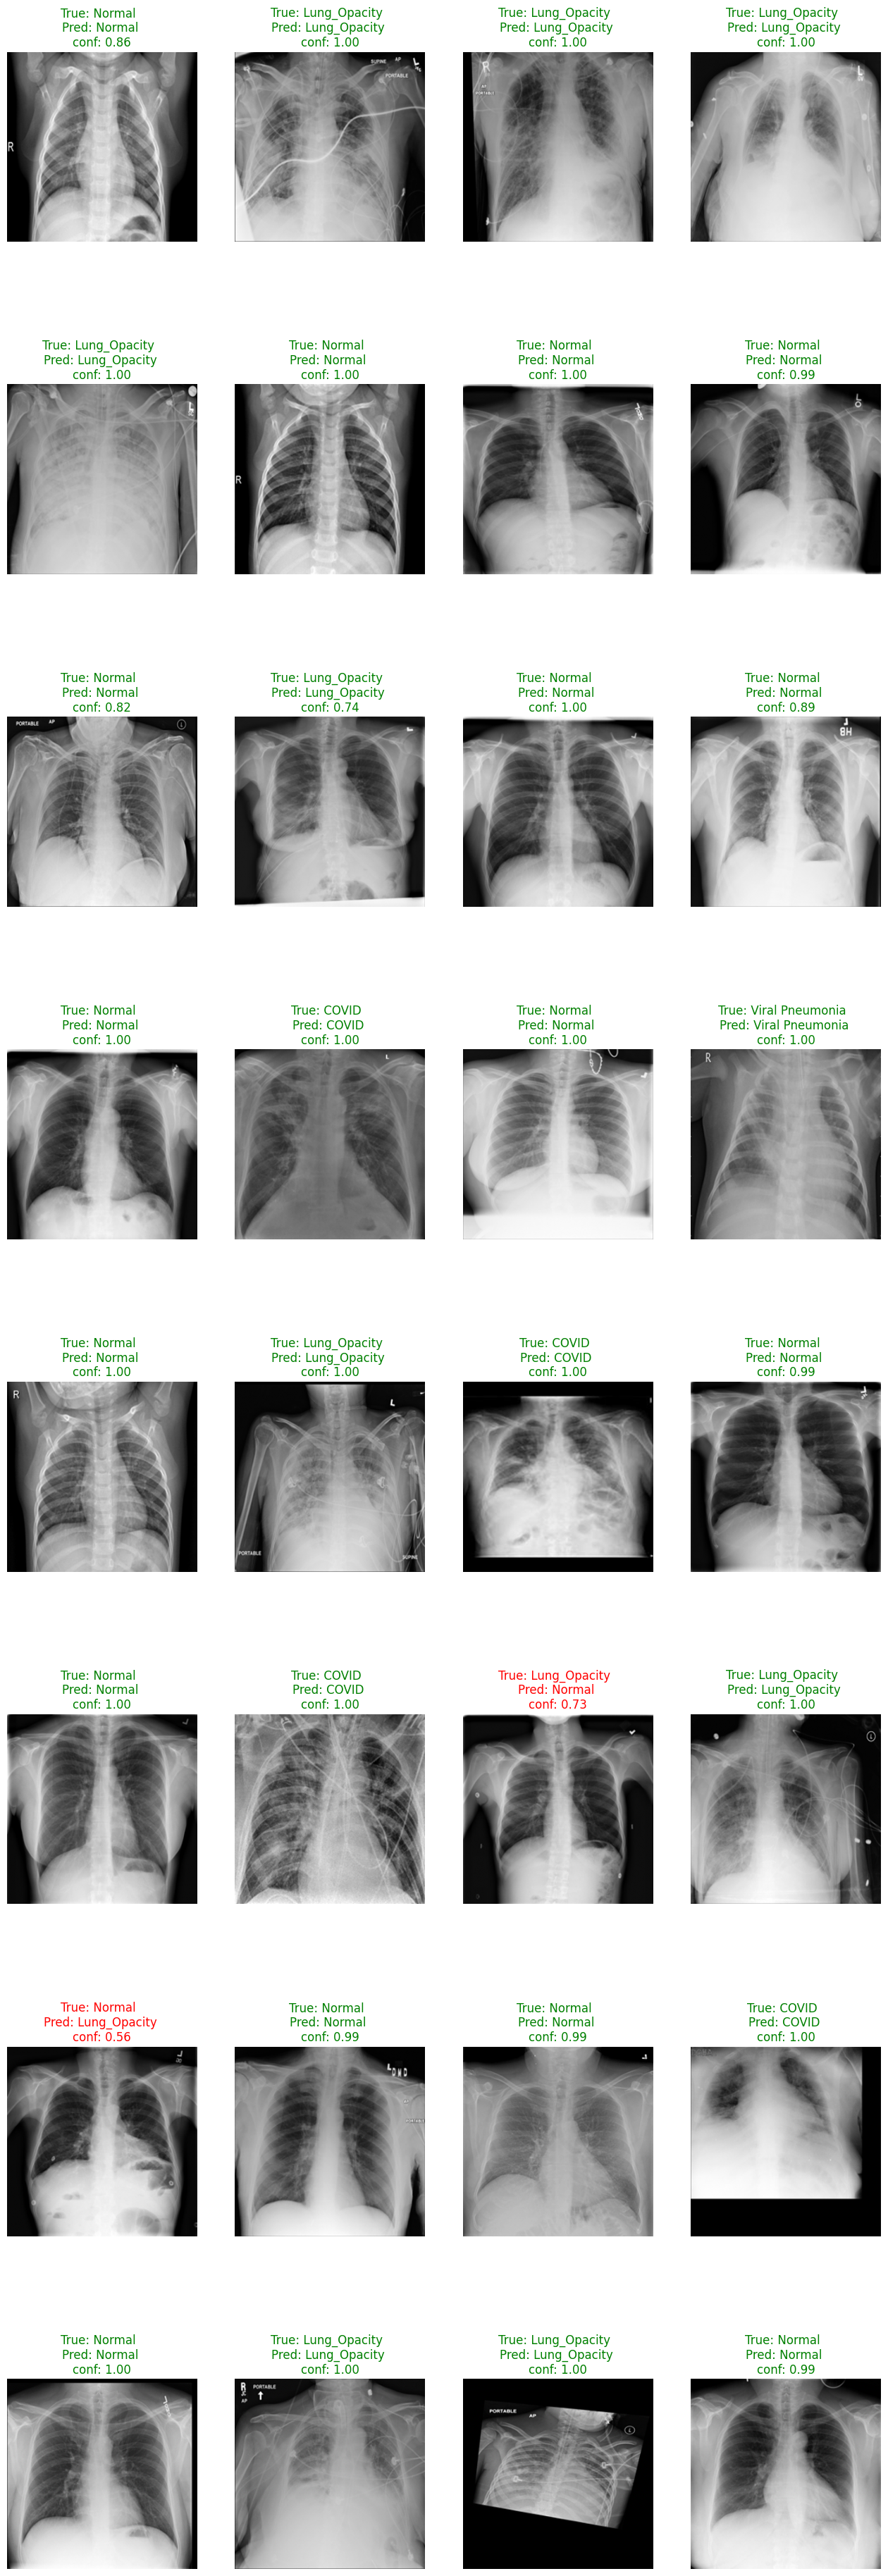

In [8]:
test_gen1 = test_generator
image_batch, label_batch = next(test_gen1)
# Randomly select an image batch from the test generator
image_batch, label_batch = next(test_generator)
# Make predictions for the selected image batch
predictions = model.predict(image_batch)
# predictions

# Create a figure with 8x4 subplots
fig, axs = plt.subplots(8, 4, figsize=(16, 48))

# Loop through the image batch
for i in range(bs):
    # Select an image from the batch
    img = image_batch[i]

    # Display the image on its corresponding subplot
    axs.flat[i].imshow(img.reshape((height, width)), cmap='gray')
    axs.flat[i].axis('off')

# Make predictions for the selected image batch
# predictions = model.predict(image_batch)
# image_batch, label_batch = next(test_generator)

# Loop through the predicted labels and their confidences
t, f = 0, 0
for i in range(bs):
    # Select a prediction from the batch
    pred = predictions[i]
    true_label = label_batch[i]
    # Get the predicted label and its confidence
    test_label = np.argmax(true_label)
    predicted_label = np.argmax(pred)
    # print(predicted_label)
    confidence = pred[predicted_label]

    # Print the predicted label and its confidence under each image
    if labels[predicted_label] == labels[test_label]:
        axs.flat[i].set_title(f"True: {labels[test_label]}  \nPred: {labels[predicted_label]} \nconf: {confidence:.2f}", color="green")
        t += 1
        
    if labels[predicted_label] != labels[test_label]:
        axs.flat[i].set_title(f"True: {labels[test_label]}  \nPred: {labels[predicted_label]} \nconf: {confidence:.2f}", color="red")
        f += 1
accuracy = t / (t+f)
loss = (1/bs) * pow(f, 2)
print("accuracy is: ", accuracy, "\nloss is: ", loss, f". {t} true confidence in {bs} data")

# Show the plot
plt.show()

